# FFS: zera i darki (złe kolumny, wiersze i piksele)

Maski defektów detektora robimy na klatkach kalibracyjnych, **bez gwiazd**: zerach (bias), darkach, flatach.
Najlepiej na **masterze** (mediana kilku klatek), bo ma mniej szumu i nie ma promieni kosmicznych.
Na pojedynczym darku hot piksel i cosmic ray wyglądają tak samo.

Każdy defekt to dwa kroki: **mapa** w ADU (można ją obejrzeć) i **maska** z progiem, który wybierasz sam:

| mapa | maska |
|---|---|
| `mk_columns_map(block, window)` daje `maps["columns"]`, `maps["rows"]` | `mk_bad_columns_mask(threshold)` daje `masks["bad_columns"]`, `masks["bad_rows"]` |
| `mk_pixels_map(size)` daje `maps["pixels"]` | `mk_hot_pixels_mask(threshold)`, `mk_cold_pixels_mask(threshold)` |

- `maps["columns"]`: mediana kolumny w blokach po `block` wierszy (po odjęciu `maps["sky"]`) minus mediana
  `window` sąsiednich kolumn. Analogicznie `maps["rows"]`.
- `maps["pixels"]`: piksel minus mediana z otoczenia `size × size`.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))   # pyaraucaria z tego repozytorium, nie z instalacji w kernelu
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from pyaraucaria.ffs import FFS
import pyaraucaria
print("pyaraucaria z:", os.path.dirname(pyaraucaria.__file__))

DATA = os.path.expanduser("~/work/data/fits_examples")
# kolory masek: stala kolejnosc (niebieski, pomaranczowy, morski, zolty)
C1, C2, C3, C4 = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"


def show(ax, img, title="", lo=1, hi=99.5, cmap="gray"):
    """Obraz w skali percentyli lo..hi."""
    vmin, vmax = np.nanpercentile(img, [lo, hi])
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax, origin="lower", interpolation="nearest")
    ax.set_title(title)


def overlay(ax, mask, color, label):
    """Polprzezroczysta maska jednego koloru (z etykieta do legendy)."""
    rgba = np.zeros(mask.shape + (4,))
    rgba[mask] = list(int(color[i:i + 2], 16) / 255 for i in (1, 3, 5)) + [0.8]
    ax.imshow(rgba, origin="lower", interpolation="nearest")
    ax.plot([], [], "s", color=color, label=f"{label} ({int(mask.sum())} px)")

from astropy.stats import mad_std

pyaraucaria z: /Users/mgorski/work/src/pyaraucaria/pyaraucaria


## 1. Master zero: zb08 (2048²)

In [2]:
zero_files = ["zb08c_0598_86317.fits", "zb08c_0598_86349.fits", "zb08c_0607_46093.fits", "zb08c_0607_46104.fits"]
zeros = [fits.getdata(os.path.join(DATA, f)).astype(float) for f in zero_files]
master = np.median(zeros, axis=0)

single = FFS(zeros[0]); single.mk_stats()
zb = FFS(master); zb.mk_stats()
print(f"pojedyncze zero: mediana {single.median:.1f}, q_sigma {single.q_sigma:.2f} ADU")
print(f"master z {len(zeros)}:      mediana {zb.median:.1f}, q_sigma {zb.q_sigma:.2f} ADU")

pojedyncze zero: mediana 300.0, q_sigma 7.00 ADU
master z 4:      mediana 300.0, q_sigma 3.75 ADU


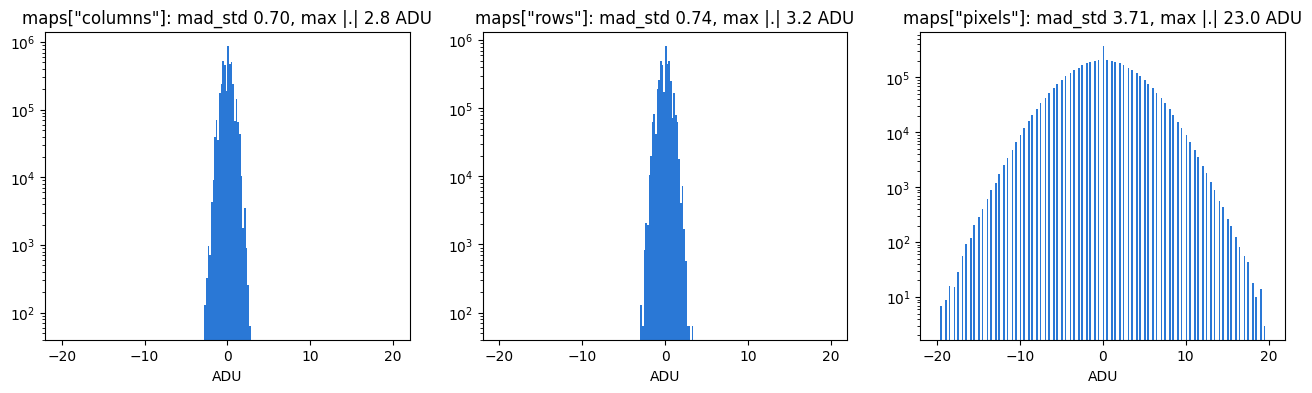

In [3]:
zb.mk_columns_map()               # block=64, window=15
zb.mk_pixels_map()                # size=5

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
for ax, name in zip(axs, ("columns", "rows", "pixels")):
    m = zb.maps[name]
    ax.hist(m.ravel(), bins=200, range=(-20, 20), color=C1, log=True)
    ax.set_title(f'maps["{name}"]: mad_std {mad_std(m):.2f}, max |.| {np.abs(m).max():.1f} ADU')
    ax.set_xlabel("ADU")
plt.show()

Detektor zb08 jest czysty. Na mapach nie ma żadnej kolumny, wiersza ani piksela odstającego o więcej niż
kilka ADU, a rozkłady są wąskie. Dowolny rozsądny próg, np. 5× `mad_std`, daje puste maski:

In [4]:
zb.mk_bad_columns_mask(threshold=5)
zb.mk_hot_pixels_mask(threshold=30)
zb.mk_cold_pixels_mask(threshold=30)
for name in ("bad_columns", "bad_rows", "hot_pixels", "cold_pixels"):
    print(f"{name:12s} {zb.masks[name].sum():6d} px   {zb.masks_description[name]}")

bad_columns       0 px   Bad columns: |maps['columns']| > 5 ADU (mk_bad_columns_mask)
bad_rows          0 px   Bad rows: |maps['rows']| > 5 ADU (mk_bad_columns_mask)
hot_pixels        0 px   Hot pixels: maps['pixels'] > 30 ADU (mk_hot_pixels_mask)
cold_pixels       0 px   Cold pixels: maps['pixels'] < -30 ADU (mk_cold_pixels_mask)


## 2. Master zero: jk15c (4096×4108)

Kamera jk15c ma cztery wzmacniacze. Kwadranty mają różne poziomy biasu, a granica między nimi leży ok.
x = 2048–2057 i y = 2041–2052. Mapa tła z 10 segmentów nie odda skoku poziomu, więc ustawiamy więcej segmentów.

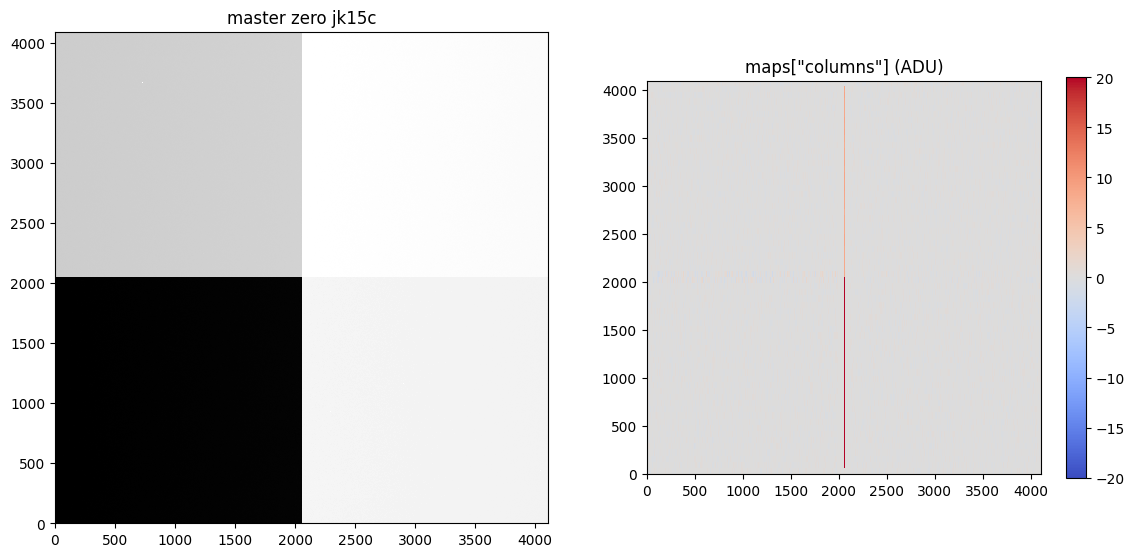

In [5]:
files = ["jk15c_0612_75680.fits", "jk15c_0655_01058.fits"]
jmaster = np.median([fits.getdata(os.path.join(DATA, f)).astype(float) for f in files], axis=0)

jk = FFS(jmaster)
jk.mk_stats()
jk.sky_map(n_segments=32)
jk.mk_columns_map()
jk.mk_pixels_map()

fig, axs = plt.subplots(1, 2, figsize=(14, 6.5))
show(axs[0], jmaster, "master zero jk15c")
lim = 20
im = axs[1].imshow(jk.maps["columns"], origin="lower", cmap="coolwarm", vmin=-lim, vmax=lim, interpolation="nearest")
axs[1].set_title('maps["columns"] (ADU)')
fig.colorbar(im, ax=axs[1], shrink=0.8)
plt.show()

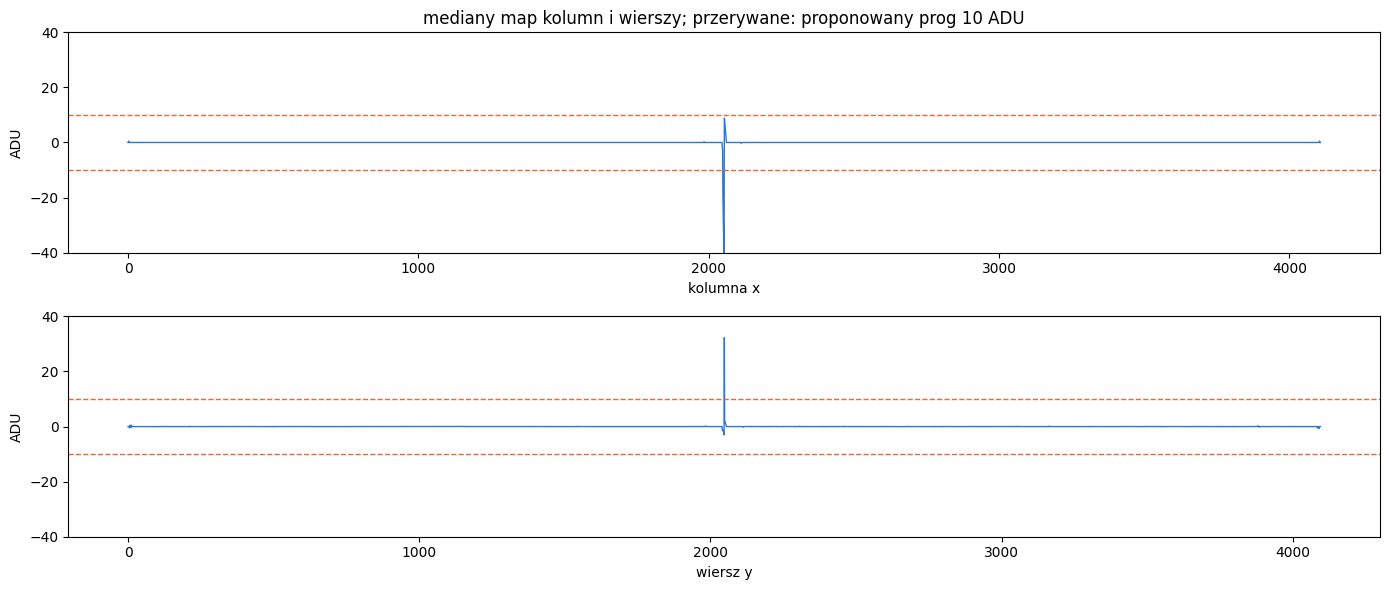

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharey=True)
col_profile = np.median(jk.maps["columns"], axis=0)    # mediana po wierszach
row_profile = np.median(jk.maps["rows"], axis=1)
axs[0].plot(col_profile, color=C1, lw=1); axs[0].set_xlabel("kolumna x")
axs[1].plot(row_profile, color=C1, lw=1); axs[1].set_xlabel("wiersz y")
for ax in axs:
    ax.set_ylabel("ADU"); ax.set_ylim(-40, 40)
    for t in (10, -10):
        ax.axhline(t, color=C2, ls="--", lw=1)
axs[0].set_title("mediany map kolumn i wierszy; przerywane: proponowany prog 10 ADU")
plt.tight_layout(); plt.show()

In [7]:
jk.mk_bad_columns_mask(threshold=10)
cols = sorted(set(np.nonzero(jk.masks["bad_columns"])[1].tolist()))
rows = sorted(set(np.nonzero(jk.masks["bad_rows"])[0].tolist()))
print("zle kolumny:", cols)
print("zle wiersze:", rows)

zle kolumny: [1, 2, 2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058, 2059, 4105, 4106]
zle wiersze: [1472, 2042, 2043, 2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053]


Co wychodzi:
- **brzegi kadru** (kolumny 1–2 i ostatnie),
- **granica kwadrantów** (pas ok. 10 kolumn i wierszy przy środku). To nie są uszkodzone kolumny, tylko skok
  poziomu między wzmacniaczami. Do fotometrii i tak warto je maskować,
- **wiersz 1472** (i blisko 1481): pojedynczy wiersz odstający od sąsiadów.

Próg jest w ADU, więc łatwo go dobrać z wykresu powyżej.

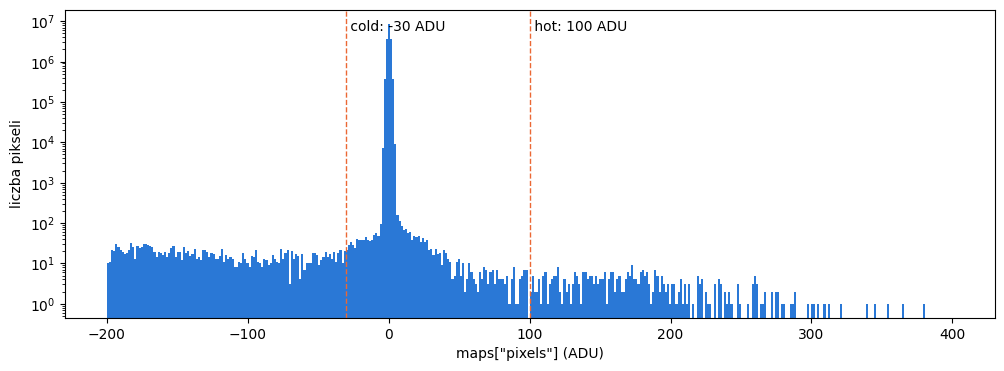

hot_pixels      460 px
cold_pixels    3161 px


In [8]:
p = jk.maps["pixels"]
fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(p.ravel(), bins=400, range=(-200, 400), color=C1, log=True)
for t, lab in ((100, "hot: 100 ADU"), (-30, "cold: -30 ADU")):
    ax.axvline(t, color=C2, ls="--", lw=1)
    ax.text(t, ax.get_ylim()[1] * 0.3, " " + lab)
ax.set_xlabel('maps["pixels"] (ADU)'); ax.set_ylabel("liczba pikseli")
plt.show()

jk.mk_hot_pixels_mask(threshold=100)
jk.mk_cold_pixels_mask(threshold=30)
for name in ("hot_pixels", "cold_pixels"):
    print(f"{name:12s} {jk.masks[name].sum():6d} px")

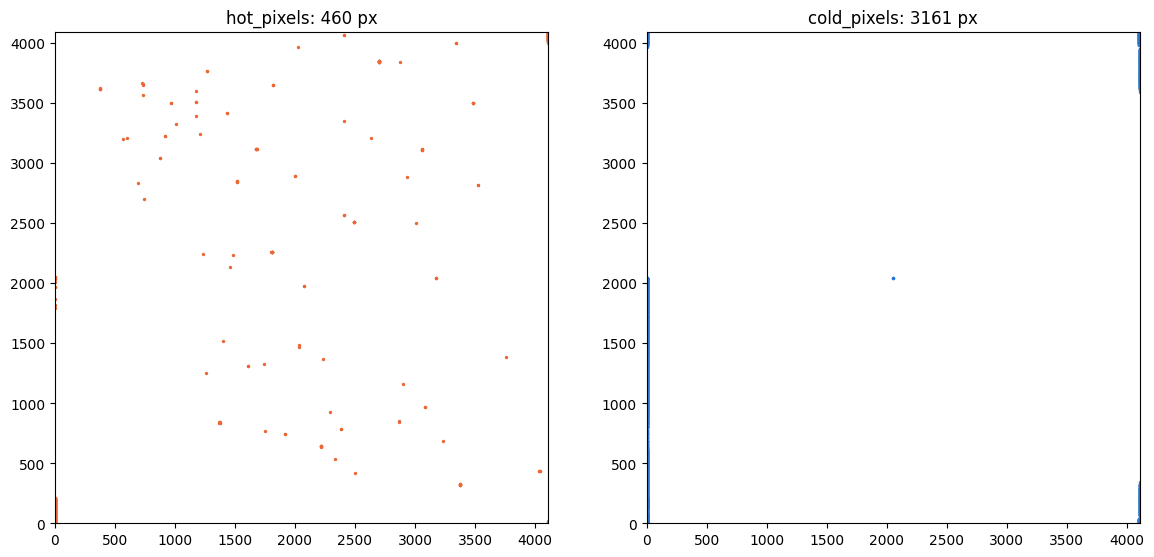

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, (name, color) in zip(axs, (("hot_pixels", C2), ("cold_pixels", C1))):
    ys, xs = np.nonzero(jk.masks[name])
    ax.scatter(xs, ys, s=2, color=color)
    ax.set_xlim(0, jmaster.shape[1]); ax.set_ylim(0, jmaster.shape[0]); ax.set_aspect("equal")
    ax.set_title(f"{name}: {len(xs)} px")
plt.show()

## 3. Dark

W przykładach nie ma prawdziwego darku, więc pokazujemy syntetyczny: poziom 50 ADU z szumem Poissona i odczytu,
lekki gradient, 300 hot pikseli, gorąca kolumna, kolumna gorąca od połowy kadru i ciemny (martwy) fragment kolumny.

Progi dobieramy z rozkładu mapy: k × `mad_std` (tu k = 6).

In [10]:
from tests.ffs_synth import make_frame

rng = np.random.default_rng(3)
hot = [(int(x), int(y), float(a)) for x, y, a in zip(rng.integers(0, 1024, 300), rng.integers(0, 1024, 300),
                                                     rng.uniform(80, 3000, 300))]
columns = [dict(x=200, kind="hot", value=25), dict(x=640, kind="hot", value=40, y0=512, y1=1024),
           dict(x=870, kind="dead", value=0.5, y0=0, y1=400)]
dark = make_frame(shape=(1024, 1024), sky=50, sky_curvature=2e-5, read_noise=5, hot_pixels=hot,
                  bad_columns=columns, seed=11).image

dk = FFS(dark)
dk.mk_stats()
dk.sky_map(n_segments=16)
dk.mk_columns_map()
dk.mk_pixels_map()

thr_columns = 6 * mad_std(dk.maps["columns"])
thr_pixels = 6 * mad_std(dk.maps["pixels"])
print(f"progi: kolumny {thr_columns:.1f} ADU, piksele {thr_pixels:.1f} ADU")
dk.mk_bad_columns_mask(threshold=thr_columns)
dk.mk_hot_pixels_mask(threshold=thr_pixels)

found = sorted(set(np.nonzero(dk.masks["bad_columns"])[1].tolist()))
print("zle kolumny:", found, "(prawda: 200, 640, 870)")
truth = np.zeros(dark.shape, bool)
for x, y, a in hot:
    truth[y, x] = True
print(f"hot piksele: {dk.masks['hot_pixels'].sum()} znalezionych, {(dk.masks['hot_pixels'] & truth).sum()} z {truth.sum()} prawdziwych")

progi: kolumny 7.6 ADU, piksele 50.9 ADU
zle kolumny: [200, 640, 870] (prawda: 200, 640, 870)
hot piksele: 337 znalezionych, 300 z 300 prawdziwych


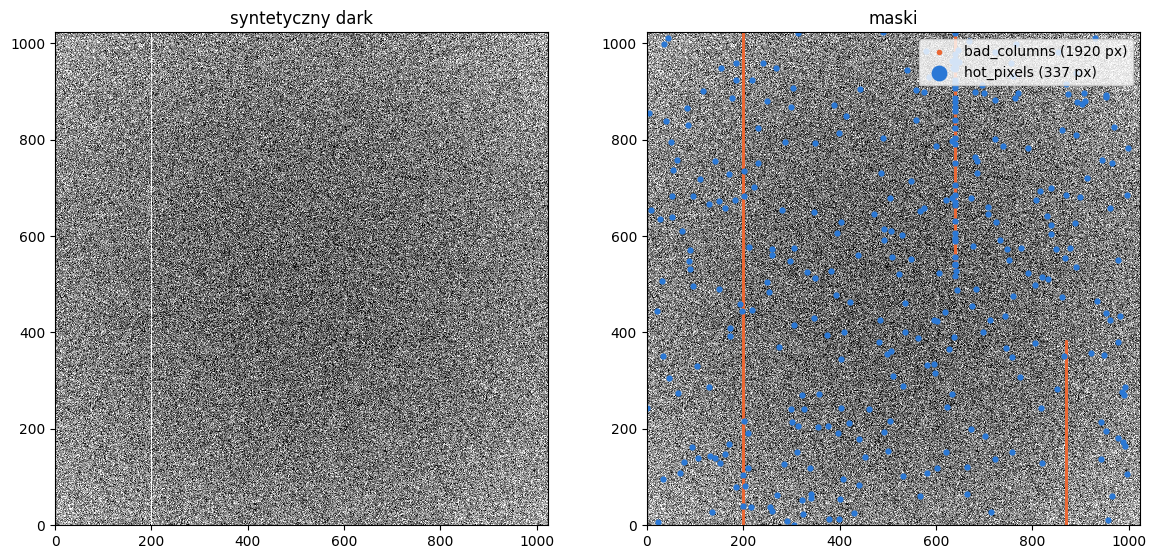

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6.5))
show(axs[0], dark, "syntetyczny dark", lo=1, hi=99)
# maski 1-px nie byloby widac jako nakladki, wiec rysujemy polozenia zamaskowanych pikseli
show(axs[1], dark, "maski", lo=1, hi=99)
for name, color, size in (("bad_columns", C2, 1), ("hot_pixels", C1, 12)):
    ys, xs = np.nonzero(dk.masks[name])
    axs[1].scatter(xs, ys, s=size, color=color, label=f"{name} ({len(xs)} px)")
axs[1].legend(loc="upper right", markerscale=3)
plt.show()

Kolumna 640 jest zaznaczona od wiersza ok. 512 w górę (bloki po 64 wiersze), a 870 tylko na dole, tam gdzie
jest defekt. Wiersze nie mają tu defektów.

Wszystkie 300 hot pikseli jest znalezionych. Dodatkowe zaznaczone piksele leżą głównie w gorącej kolumnie 640
(+40 ADU plus szum przekracza próg), są więc i tak złe.

## 4. Zapis maski i użycie na klatce naukowej

Maski zapisujemy jako jedną bitmaskę FITS (`uint8`: bit 0 to złe kolumny, 1 złe wiersze, 2 hot, 3 cold).
Na klatce naukowej z tego samego detektora wpisujemy je do `masks` i do `exclude`. Statystyki, mapa tła,
detekcja gwiazd i linii pominą wtedy te piksele.

Przykład na wycinku jk15c 1024×1024, bo pełna klatka 4k nie zmieści się jeszcze w `find_lines()`
(do czasu binowania).

In [12]:
import tempfile
BITS = {"bad_columns": 1, "bad_rows": 2, "hot_pixels": 4, "cold_pixels": 8}

bitmask = np.zeros(jmaster.shape, np.uint8)
for name, bit in BITS.items():
    bitmask[jk.masks[name]] |= bit
path = os.path.join(tempfile.gettempdir(), "mask_jk15c.fits")
fits.writeto(path, bitmask, overwrite=True)
print("zapisano", path, {k: int(((bitmask & b) > 0).sum()) for k, b in BITS.items()})

zapisano /var/folders/d1/n39w6bbs3f1_3tml2k1fftww0000gn/T/mask_jk15c.fits {'bad_columns': 25728, 'bad_rows': 24061, 'hot_pixels': 460, 'cold_pixels': 3161}


In [13]:
cut = (slice(1500, 2524), slice(1500, 2524))      # wycinek z granica kwadrantow
science = fits.getdata(os.path.join(DATA, "jk15c_0154_73367.fits")).astype(float)[cut]
bits = fits.getdata(path)[cut]

results = {}
for use_mask in (False, True):
    sc = FFS(science)
    sc.saturation = 45000
    if use_mask:
        for name, bit in BITS.items():
            sc.masks[name] = (bits & bit) > 0
            sc.exclude.add(name)
    sc.calc_frame_fwhm(N_stars=50)
    results[use_mask] = sc
    print(f"{'z maska ' if use_mask else 'bez maski'}: gwiazdy {len(sc.coo):3d}, linie {len(sc.lines)}, "
          f"fwhm {sc.stats['frame']['fwhm']:.2f}, ell {sc.stats['frame']['ellipticity']:.2f}, "
          f"bad_mask {sc.bad_mask().sum()} px")

bez maski: gwiazdy  12, linie 0, fwhm 4.24, ell 0.14, bad_mask 0 px
z maska : gwiazdy  12, linie 0, fwhm 4.24, ell 0.14, bad_mask 13204 px


Na tym wycinku żadna mierzona gwiazda nie leży na zamaskowanych pikselach, więc FWHM się nie zmienia.
Maski działają: `bad_mask()` ma ponad 13 tys. pikseli, które statystyki, tło i detekcja pomijają.

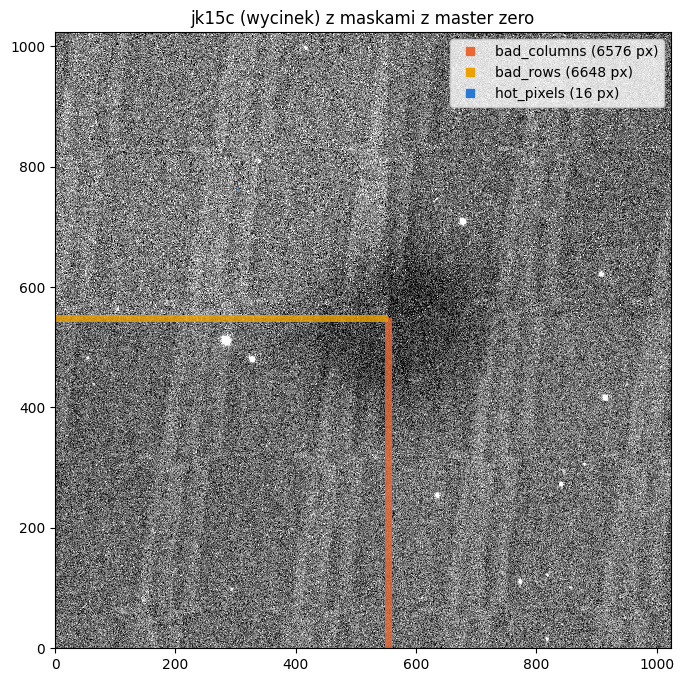

In [14]:
sc = results[True]
fig, ax = plt.subplots(figsize=(8, 8))
show(ax, science, "jk15c (wycinek) z maskami z master zero")
for name, color in (("bad_columns", C2), ("bad_rows", C4), ("hot_pixels", C1)):
    overlay(ax, sc.masks[name], color, name)
if sc.masks["lines"].any():
    overlay(ax, sc.masks["lines"], C3, "lines")
ax.legend(loc="upper right")
plt.show()